# Fuel Cost-Shock Forecaster — Multi-Agent Setup

Adapted from the [`energy_oil_forecasting`](../energy_oil_forecasting/) (WTI) reference implementation. Full objectives: [`../../fuel-cost-shock-forecaster/Fuel_Cost_Shock_Forecaster_Objectives_and_Requirements.md`](../../fuel-cost-shock-forecaster/Fuel_Cost_Shock_Forecaster_Objectives_and_Requirements.md).

**Bootcamp convention: everything lives in this notebook.** No `data.py` / `tasks.py` / `news_agent/` / `forecaster_agent/` package modules — the Commodity-Data ingestion, the Geopolitical/News Agent, the Forecaster Agent, and the task specs are all defined inline below so the whole multi-agent pipeline runs top-to-bottom from this one file.

**Architecture: 3 agents, no Adjudicator.** The Adjudicator agent from the original objectives doc was dropped — there's no existing pattern in this repo for multi-run adjudication to build on, and its "flag the dominant market drivers" job is already covered by `DiscreteAgentForecastOutput.key_signals` / `.reasoning` on the Forecaster Agent's shock output (see the shock task spec below).

| Agent | Section | Role |
|---|---|---|
| Commodity-Data Agent | §2 | `DataService` registration: yfinance (jet-fuel proxy, WTI, USD index) + FRED (CAD/USD FX) + EIA (crude/jet-fuel spot) + the derived cost-shock event series |
| Geopolitical/News Agent | §3 | `ContextRetrievalConfig` sub-agent (`search_web` tool) with a temporal-leakage verifier |
| Forecaster Agent | §4 | Top-level `AgentConfig`; "one agent, two tasks" — binary shock (primary) + continuous trajectory (secondary) |

**Targets:**
- **Primary (binary):** P(jet-fuel proxy rises > 10% over the next 21 trading days).
- **Secondary (continuous):** jet-fuel proxy point forecast at 5/10/21 trading days.

**Jet-fuel proxy:** no liquid public jet-fuel futures contract exists, so NY Harbor ULSD / Heating Oil (`HO=F`) is used — the standard middle-distillate proxy convention (jet fuel prices as a spread off heating oil / diesel).

In [21]:
import json
import os
import warnings
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from IPython.display import Markdown, display  # noqa: A004

from aieng.forecasting.data import DataService, SeriesMetadata
from aieng.forecasting.data.adapters.base import BaseAdapter
from aieng.forecasting.data.adapters.fred import FREDAdapter
from aieng.forecasting.data.adapters.yfinance import YFinanceDailyAdapter
from aieng.forecasting.data.context import ForecastContext
from aieng.forecasting.evaluation.backtest import compute_brier_score
from aieng.forecasting.evaluation.prediction import STANDARD_QUANTILES
from aieng.forecasting.evaluation.task import ForecastingTask
from aieng.forecasting.methods.agentic import (
    AgentPredictor,
    ContinuousAgentForecastOutput,
    DiscreteAgentForecastOutput,
)
from aieng.forecasting.methods.agentic.agent_factory import AgentConfig, ContextRetrievalConfig
from aieng.forecasting.models import ADVANCED_MODEL, LITE_MODEL
from dotenv import load_dotenv
from pydantic import BaseModel


warnings.filterwarnings("ignore")
load_dotenv()

# ── Model selection ──────────────────────────────────────────────────────────────────────────
AGENT_MODEL = LITE_MODEL
SEARCH_MODEL = LITE_MODEL
VERIFIER_MODEL = ADVANCED_MODEL

# ── Cost-shock target definition ──────────────────────────────────────────────────
SHOCK_THRESHOLD_PCT = 0.10
SHOCK_HORIZON_DAYS = 21  # ~1 trading month
TRAJECTORY_HORIZONS = [5, 10, 21]


def naive_utc_now() -> datetime:
    """Timezone-naive current UTC time (DataService / CutoffEnforcer require this)."""
    return datetime.now(tz=timezone.utc).replace(tzinfo=None)


def repo_data_dir() -> Path:
    """Return ``data/`` at the repository root (walk up from CWD if needed)."""
    cwd = Path.cwd().resolve()
    root = cwd
    while not (root / "pyproject.toml").exists():
        if root.parent == root:
            return cwd / "data"
        root = root.parent
    data_dir = root / "data"
    data_dir.mkdir(exist_ok=True)
    return data_dir


DATA_DIR = repo_data_dir()
print(f"Data cache root: {DATA_DIR}")

Data cache root: /home/coder/agentic-forecasting/implementations/data


---
## 1. Commodity-Data Agent

Realised as a `DataService` registration layer, not a separate LLM call — every reference implementation in this repo (WTI, BoC, S&P 500) treats quantitative time-series data as a structured prompt payload, not something an agent fetches or summarizes. `FuelMultitaskPromptBuilder` (§4) builds the payload from the service below, fulfilling this agent's role structurally.

**Data sources (doc §6):**

| Source | Series | Key required? |
|---|---|---|
| yfinance | jet-fuel proxy `HO=F`, WTI `CL=F`, USD index `DX-Y.NYB` | No |
| FRED | `DEXCAUS` (CAD/USD spot FX) — stands in for the doc's "Bank of Canada Valet API" (no Valet adapter exists in this repo; FRED covers the same signal) | `FRED_API_KEY` (set) |
| EIA Open Data | `RWTC` (WTI Cushing spot), `EER_EPJK_PF4_RGC_DPG` (US Gulf Coast jet-fuel spot) — verified against `eia-api-swagger.yaml` | `EIA_API_KEY` (set) |

EIA inventory/stocks series (`petroleum/stoc/...`) are **not yet added** — not verified against the swagger file yet. GDELT 2.0 (doc's alternative news feed) is not evaluated.

In [22]:
# ── EIA Open Data adapter (API v2) ────────────────────────────────────────────────
# Not a pre-existing aieng adapter -- built here against eia-api-swagger.yaml
# (route: /v2/petroleum/{route1}/{route2}/data, params: api_key, frequency,
# data[], facets[series][], sort[0][column]/[direction], offset, length).
# Mirrors FREDAdapter's cache-to-parquet convention.

EIA_BASE_URL = "https://api.eia.gov/v2"
EIA_PAGE_LENGTH = 5000  # API max rows per request


class EIAAdapter(BaseAdapter):
    """Adapter for a single EIA Open Data API v2 petroleum series, with disk cache.

    Parameters
    ----------
    route1, route2 : str
        EIA route segments, e.g. ``"pri", "spt"`` for spot prices.
    series_id : str
        EIA facet series id, e.g. ``"RWTC"`` or ``"EER_EPJK_PF4_RGC_DPG"``.
    frequency : str
        EIA frequency string (``"daily"``, ``"weekly"``, ...).
    api_key : str or None
        EIA API key. Defaults to the ``EIA_API_KEY`` environment variable.
    cache_dir : Path or None
        Parquet cache directory. Defaults to ``data/eia``.
    refresh : bool
        Force a network re-fetch even if a cache file exists.
    """

    def __init__(
        self,
        route1: str,
        route2: str,
        series_id: str,
        *,
        frequency: str = "daily",
        api_key: str | None = None,
        cache_dir: Path | None = None,
        refresh: bool = False,
    ) -> None:
        self._route1 = route1
        self._route2 = route2
        self._series_id = series_id
        self._frequency = frequency
        self._api_key = api_key or os.environ.get("EIA_API_KEY")
        self._cache_dir = cache_dir if cache_dir is not None else DATA_DIR / "eia"
        self._refresh = refresh

    @property
    def cache_path(self) -> Path:
        return self._cache_dir / f"{self._series_id}.parquet"

    def fetch(self) -> pd.DataFrame:
        if self.cache_path.exists() and not self._refresh:
            df = pd.read_parquet(self.cache_path)
            df["timestamp"] = pd.to_datetime(df["timestamp"])
            df["released_at"] = pd.to_datetime(df["released_at"])
            return df

        df = self._fetch_from_api()
        self.cache_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(self.cache_path, index=False)
        return df

    def _fetch_from_api(self) -> pd.DataFrame:
        if not self._api_key:
            raise ValueError(
                "EIA API key not provided. Set the EIA_API_KEY environment variable "
                "or pass api_key= to EIAAdapter."
            )

        url = f"{EIA_BASE_URL}/petroleum/{self._route1}/{self._route2}/data/"
        rows: list[dict] = []
        offset = 0
        while True:
            params = {
                "api_key": self._api_key,
                "frequency": self._frequency,
                "data[0]": "value",
                "facets[series][]": self._series_id,
                "sort[0][column]": "period",
                "sort[0][direction]": "asc",
                "offset": offset,
                "length": EIA_PAGE_LENGTH,
            }
            resp = requests.get(url, params=params, timeout=30)
            resp.raise_for_status()
            payload = resp.json()["response"]
            page = payload["data"]
            rows.extend(page)
            if len(page) < EIA_PAGE_LENGTH:
                break
            offset += EIA_PAGE_LENGTH

        if not rows:
            raise RuntimeError(f"EIA series '{self._series_id}' returned no data.")

        df = pd.DataFrame(rows)
        df["timestamp"] = pd.to_datetime(df["period"])
        df["value"] = pd.to_numeric(df["value"], errors="coerce")
        df = df.dropna(subset=["value"]).sort_values("timestamp").reset_index(drop=True)
        df["released_at"] = df["timestamp"]  # EIA doesn't expose vintage dates via this route
        return df[["timestamp", "value", "released_at"]]

    def __repr__(self) -> str:
        return f"EIAAdapter(route={self._route1}/{self._route2}, series_id={self._series_id!r})"


print("EIAAdapter defined.")

EIAAdapter defined.


In [23]:
# ── Canonical series IDs ───────────────────────────────────────────────────────────────
FUEL_SERIES_ID = "jet_fuel_proxy_price"  # yfinance HO=F -- primary target
WTI_SERIES_ID = "wti_crude_oil_price"  # yfinance CL=F -- covariate
USD_INDEX_SERIES_ID = "usd_index_price"  # yfinance DX-Y.NYB -- covariate
CAD_USD_FX_SERIES_ID = "cad_usd_fx_rate"  # FRED DEXCAUS -- covariate
EIA_WTI_SPOT_SERIES_ID = "eia_wti_spot_price"  # EIA RWTC -- covariate
EIA_JET_FUEL_SPOT_SERIES_ID = "eia_jet_fuel_spot_price"  # EIA EER_EPJK_PF4_RGC_DPG -- covariate
SHOCK_EVENT_SERIES_ID = "fuel_cost_shock_event_21d"  # derived binary series -- primary task target

_FUEL_TICKER = "HO=F"
_WTI_TICKER = "CL=F"
_USD_INDEX_TICKER = "DX-Y.NYB"
_HISTORY_START = "2004-01-01"


def derive_shock_event_series(
    price_df: pd.DataFrame,
    *,
    horizon_days: int = SHOCK_HORIZON_DAYS,
    threshold_pct: float = SHOCK_THRESHOLD_PCT,
) -> pd.DataFrame:
    """Derive the rolling binary cost-shock event series from a daily price series.

    For each row at date ``t``, looks ``horizon_days`` trading rows ahead to date
    ``t+h`` and sets ``value = 1.0`` if ``price[t+h] / price[t] - 1 > threshold_pct``,
    else ``0.0``. ``released_at`` is set to ``t+h`` -- the event is only knowable
    once the horizon has resolved -- so ``CutoffEnforcer`` correctly hides it from
    any origin before that date.
    """
    df = price_df.sort_values("timestamp").reset_index(drop=True)
    timestamps = pd.to_datetime(df["timestamp"])
    values = df["value"].astype(float)

    n = len(df)
    if n <= horizon_days:
        return pd.DataFrame(columns=["timestamp", "value", "released_at"])

    origin = values.iloc[: n - horizon_days].reset_index(drop=True)
    resolved = values.iloc[horizon_days:].reset_index(drop=True)
    pct_change = resolved / origin - 1.0

    return pd.DataFrame(
        {
            "timestamp": timestamps.iloc[: n - horizon_days].reset_index(drop=True),
            "value": (pct_change > threshold_pct).astype(float),
            "released_at": timestamps.iloc[horizon_days:].reset_index(drop=True),
        }
    )


class FuelShockEventAdapter(BaseAdapter):
    """Adapter producing the derived rolling cost-shock event series.

    Wraps the underlying price adapter and recomputes the derived series at
    fetch time, so it always reflects the freshest cached price data.
    """

    def __init__(self, price_adapter: BaseAdapter, *, horizon_days: int = SHOCK_HORIZON_DAYS, threshold_pct: float = SHOCK_THRESHOLD_PCT) -> None:
        self._price_adapter = price_adapter
        self._horizon_days = horizon_days
        self._threshold_pct = threshold_pct

    def fetch(self) -> pd.DataFrame:
        price_df = self._price_adapter.fetch()
        return derive_shock_event_series(price_df, horizon_days=self._horizon_days, threshold_pct=self._threshold_pct)


def build_fuel_service(cache_dir: Path | None = None) -> DataService:
    """Return a :class:`DataService` with the fuel cost-shock series registered.

    Registers the jet-fuel proxy target, the derived shock-event series, and
    the WTI / USD-index / CAD-USD-FX / EIA-spot covariates.
    """
    resolved_cache_dir = cache_dir if cache_dir is not None else DATA_DIR / "yfinance"
    svc = DataService()

    fuel_adapter = YFinanceDailyAdapter(ticker=_FUEL_TICKER, start=_HISTORY_START, cache_dir=resolved_cache_dir)
    svc.register(
        FUEL_SERIES_ID,
        fuel_adapter,
        SeriesMetadata(
            series_id=FUEL_SERIES_ID,
            description="NY Harbor ULSD / Heating Oil front-month futures adjusted close (Yahoo Finance HO=F) -- jet-fuel proxy.",
            source="yfinance",
            units="USD/gal",
            frequency="B",
        ),
    )

    svc.register(
        SHOCK_EVENT_SERIES_ID,
        FuelShockEventAdapter(fuel_adapter),
        SeriesMetadata(
            series_id=SHOCK_EVENT_SERIES_ID,
            description=(
                f"Cost-shock indicator: 1.0 if {FUEL_SERIES_ID} rises more than "
                f"{SHOCK_THRESHOLD_PCT:.0%} over the following {SHOCK_HORIZON_DAYS} business days, else 0.0."
            ),
            source=f"Derived ({FUEL_SERIES_ID})",
            units="0/1 event indicator",
            frequency="B",
        ),
    )

    svc.register(
        WTI_SERIES_ID,
        YFinanceDailyAdapter(ticker=_WTI_TICKER, start=_HISTORY_START, cache_dir=resolved_cache_dir),
        SeriesMetadata(
            series_id=WTI_SERIES_ID,
            description="WTI Crude Oil front-month futures adjusted close (Yahoo Finance CL=F)",
            source="yfinance",
            units="USD/bbl",
            frequency="B",
        ),
    )

    svc.register(
        USD_INDEX_SERIES_ID,
        YFinanceDailyAdapter(ticker=_USD_INDEX_TICKER, field="Adj Close", start=_HISTORY_START, cache_dir=resolved_cache_dir),
        SeriesMetadata(
            series_id=USD_INDEX_SERIES_ID,
            description="US Dollar Index close level (Yahoo Finance DX-Y.NYB)",
            source="yfinance",
            units="index-level",
            frequency="B",
        ),
    )

    try:
        svc.register(
            CAD_USD_FX_SERIES_ID,
            FREDAdapter("DEXCAUS", cache_dir=DATA_DIR / "fred"),
            SeriesMetadata(
                series_id=CAD_USD_FX_SERIES_ID,
                description="Canadian Dollars to U.S. Dollar spot exchange rate (FRED DEXCAUS)",
                source="FRED (DEXCAUS)",
                units="CAD per USD",
                frequency="B",
            ),
        )
    except (RuntimeError, ValueError) as exc:
        warnings.warn(f"Skipping CAD/USD FX (FRED): {exc}", stacklevel=2)

    try:
        svc.register(
            EIA_WTI_SPOT_SERIES_ID,
            EIAAdapter("pri", "spt", "RWTC"),
            SeriesMetadata(
                series_id=EIA_WTI_SPOT_SERIES_ID,
                description="Cushing, OK WTI spot price FOB (EIA RWTC)",
                source="EIA Open Data (petroleum/pri/spt, RWTC)",
                units="USD/bbl",
                frequency="B",
            ),
        )
        svc.register(
            EIA_JET_FUEL_SPOT_SERIES_ID,
            EIAAdapter("pri", "spt", "EER_EPJK_PF4_RGC_DPG"),
            SeriesMetadata(
                series_id=EIA_JET_FUEL_SPOT_SERIES_ID,
                description="US Gulf Coast kerosene-type jet-fuel spot price FOB (EIA EER_EPJK_PF4_RGC_DPG)",
                source="EIA Open Data (petroleum/pri/spt, EER_EPJK_PF4_RGC_DPG)",
                units="USD/gal",
                frequency="B",
            ),
        )
    except (RuntimeError, ValueError) as exc:
        warnings.warn(f"Skipping EIA spot-price covariates: {exc}", stacklevel=2)

    return svc


print("build_fuel_service() defined.")

build_fuel_service() defined.


In [24]:
# Build the service and preview the price history through today.
data_service = build_fuel_service()
ctx0 = data_service.context(as_of=naive_utc_now())
fuel_df = ctx0.get_series(FUEL_SERIES_ID)
print(f"Jet-fuel proxy (HO=F) history through {pd.Timestamp(fuel_df['timestamp'].max()).date()}, {len(fuel_df)} rows")
print(f"Registered series: {list(data_service.series_ids)}")

Jet-fuel proxy (HO=F) history through 2026-09-23, 5714 rows
Registered series: ['cad_usd_fx_rate', 'eia_jet_fuel_spot_price', 'eia_wti_spot_price', 'fuel_cost_shock_event_21d', 'jet_fuel_proxy_price', 'usd_index_price', 'wti_crude_oil_price']


---
## 2. Geopolitical / News Agent

A `ContextRetrievalConfig` sub-agent (the same primitive `energy_oil_forecasting` uses for its news-grounded configs) with a temporal-leakage verifier, wired into the Forecaster Agent below as the `search_web` tool. GDELT 2.0 (doc's alternative feed) is not wired up here.

In [25]:
FUEL_NEWS_INSTRUCTION = """
You are a jet-fuel and crude-oil market intelligence specialist with access to web search.

Search for information relevant to the query and return a concise structured markdown summary (3-5 paragraphs) covering relevant aspects of:
- Crude oil (WTI/Brent) and refined-products (jet fuel / heating oil / diesel) price level and recent trend
- OPEC+ production decisions and supply outlook
- Geopolitical risks in the Persian Gulf, Middle East, Strait of Hormuz, and other key shipping lanes affecting crude and product tanker flows
- US EIA policy releases, Strategic Petroleum Reserve actions, and inventory data surprises
- Refinery outages or disruptions affecting jet fuel / distillate supply
- Notable analyst forecasts or unusual price-target revisions for crude or refined products

Ground your summary in the search results you actually retrieve. When a cutoff date is specified, do not report or speculate about events that occurred after that date.

Before finalizing your summary, reason step by step: (1) for each candidate fact, judge its actual recency from the substance of the result itself, never from a source's claimed publish date or byline timestamp -- those are frequently stale or updated after original publication; (2) discard anything you cannot confidently place before the cutoff date; (3) only then write your summary. Do not supplement the search results with your own background/training knowledge -- if the results are insufficient, say so explicitly rather than filling gaps from memory.
""".strip()

FUEL_CONTEXT_RETRIEVAL_SUPPLEMENT = """

## Context retrieval

Call ``search_web`` to gather market intelligence BEFORE producing forecasts.

Call ``search_web`` with ``query`` and ``cutoff_date`` (set to the ``as_of`` date from the payload). The ``cutoff_date`` MUST always equal ``as_of`` -- this is the temporal fence that prevents post-origin information from contaminating historical backtests.

If ``search_web`` returns a result beginning with ``[SEARCH_VERIFICATION_FAILED]``, treat it as no verified news context for that query. Do not use your own background knowledge to fill the gap or speculate about what the news might have said -- proceed with price-history and other available signals only, and note the gap in your rationale.

Recommended queries (call ``search_web`` once per topic):
- ``search_web(query="crude oil and jet fuel price trend and OPEC+ supply decisions", cutoff_date=<as_of>)``
- ``search_web(query="Persian Gulf geopolitical risk shipping lane disruptions", cutoff_date=<as_of>)``
- ``search_web(query="US EIA policy releases and Strategic Petroleum Reserve actions", cutoff_date=<as_of>)``
- ``search_web(query="refinery outages affecting jet fuel and distillate supply", cutoff_date=<as_of>)``
"""


def build_fuel_context_retrieval_config(
    search_model: str = SEARCH_MODEL,
    verifier_model: str = VERIFIER_MODEL,
    verifier_max_attempts: int = 3,
    verifier_confidence_threshold: int = 8,
) -> ContextRetrievalConfig:
    """Build the Geopolitical/News Agent's :class:`ContextRetrievalConfig`."""
    return ContextRetrievalConfig(
        enabled=True,
        instruction=FUEL_NEWS_INSTRUCTION,
        search_model=search_model,
        verifier_model=verifier_model,
        verifier_max_attempts=verifier_max_attempts,
        verifier_confidence_threshold=verifier_confidence_threshold,
    )


print("News Agent instruction + factory defined.")

News Agent instruction + factory defined.


---
## 3. Forecaster Agent

"One agent, two tasks": a single identity, with the ask living in each call's `task_spec` (not the system instruction). `FuelMultitaskPromptBuilder` builds the payload from the Commodity-Data service above.

In [26]:
FUEL_FORECASTER_INSTRUCTION = """
## Role

You are an expert jet-fuel and crude-oil market analyst producing calibrated forecasts to support airline hedging, budgeting, and financial risk decisions.

## Input

You will receive a JSON payload containing:
- `task_spec`: the exact question and required JSON output schema
- `as_of`: the forecast origin date (temporal cutoff)
- `horizons`: integer horizon steps (business days ahead)
- `standard_quantiles`: quantile levels for continuous forecasts (when applicable)
- `origin_price_usd_gal`: jet-fuel proxy (heating oil futures) close on the origin date
- `target_history_csv`: compressed jet-fuel proxy daily close history

Call ``search_web`` BEFORE answering -- it is your only source of qualitative market intelligence (OPEC+ policy, geopolitical supply risk, EIA releases); you have no other tools and no post-training-cutoff knowledge to rely on.

## Output contract

Read the data and the search briefing carefully, then execute the task in `task_spec` precisely.

If a `set_model_response` tool is available, call it with your complete JSON as `json_response` -- the exact schema is described in `task_spec`. Otherwise return the JSON directly as plain text with no preamble.
""".strip()


def build_fuel_forecaster_config(
    model: str = AGENT_MODEL,
    search_model: str = SEARCH_MODEL,
    verifier_model: str = VERIFIER_MODEL,
) -> AgentConfig:
    """Build the Forecaster Agent's :class:`AgentConfig`, wiring in the News Agent."""
    return AgentConfig(
        name="fuel_shock_forecaster",
        model=model,
        instruction=FUEL_FORECASTER_INSTRUCTION,
        context_retrieval=build_fuel_context_retrieval_config(search_model=search_model, verifier_model=verifier_model),
    )


def _compress_history(df: pd.DataFrame) -> str:
    """Compress daily price history: recent 6 months daily, older weekly averages."""
    frame = df.copy()
    frame["timestamp"] = pd.to_datetime(frame["timestamp"])
    cutoff = frame["timestamp"].max() - pd.DateOffset(months=6)

    recent = frame[frame["timestamp"] >= cutoff]
    old = frame[frame["timestamp"] < cutoff]

    rows: list[str] = ["date,close"]
    if not old.empty:
        weekly = old.set_index("timestamp")["value"].resample("W").mean().dropna()
        rows.extend(f"{date.date()},{val:.3f}" for date, val in weekly.items())
    rows.extend(f"{row['timestamp'].date()},{row['value']:.3f}" for _, row in recent.iterrows())
    return "\n".join(rows)


class FuelMultitaskPromptBuilder(BaseModel):
    """Prompt builder for task-spec-driven Forecaster Agent calls.

    The system instruction is task-agnostic; the ask lives in ``task_spec``.
    """

    task_spec: str

    model_config = {"extra": "forbid"}

    def __call__(self, *, task: ForecastingTask, context: ForecastContext) -> str:
        df = context.get_series(task.target_series_id)
        last_row = df.iloc[-1]
        payload = {
            "task": task.task_id,
            "task_spec": self.task_spec,
            "as_of": str(context.as_of)[:10],
            "horizons": list(task.horizons),
            "standard_quantiles": list(STANDARD_QUANTILES),
            "origin_price_usd_gal": float(last_row["value"]),
            "target_history_csv": _compress_history(df),
        }
        return json.dumps(payload, indent=2)


TASK_SHOCK_SPEC = (
    f"Estimate the probability that the jet-fuel proxy price will close MORE\n"
    f"THAN {SHOCK_THRESHOLD_PCT:.0%} HIGHER than today's price at the end of\n"
    f"{SHOCK_HORIZON_DAYS} trading days (the cost-shock event).\n\n"
    "This is a directional upside question only.\n\n"
    "Calibration guidance:\n"
    "  - No unusual upside catalyst       -> base rate ~10-15%\n"
    "  - Escalating unconfirmed risk      -> 20-40%\n"
    "  - Confirmed supply disruption      -> 60-85%\n\n"
    "Use `key_signals` to name the specific drivers (OPEC+ decisions, shipping-lane\n"
    "risk, inventory levels, refinery outages, macro demand) behind your estimate --\n"
    "this is the primary place downstream readers look for the 'why'.\n\n"
    "If a `set_model_response` tool is available, call it with your complete "
    "JSON as `json_response`. Otherwise return the JSON directly as plain text.\n\n"
    "Required JSON format:\n" + DiscreteAgentForecastOutput.prompt_schema_json()
)

TASK_TRAJECTORY_SPEC = (
    "Forecast the jet-fuel proxy price at each horizon listed in the payload "
    "(`horizons`, business days ahead).\n\n"
    "Rules:\n"
    "  - Produce one forecast for each horizon in `horizons`.\n"
    "  - Use exactly the quantile levels from `standard_quantiles` -- no additions, no omissions.\n"
    "  - `point_forecast` must exactly equal the 0.50 quantile value.\n"
    "  - Quantile values must be strictly non-decreasing as quantile levels increase.\n"
    "  - Document your reasoning in the `rationale` fields.\n\n"
    "If a `set_model_response` tool is available, call it with your complete "
    "JSON as `json_response`. Otherwise return the JSON directly as plain text.\n\n"
    "Required JSON format:\n" + ContinuousAgentForecastOutput.prompt_schema_json()
)

forecaster_config = build_fuel_forecaster_config()
print(f"Forecaster Agent config: {forecaster_config.name} (model={forecaster_config.model})")

Forecaster Agent config: fuel_shock_forecaster (model=gemini-3.1-flash-lite-preview)


In [27]:
# Backtest compatibility: binary shock tasks are scored against the derived event
# series, but the agent must receive the underlying HO=F price history as input.
_original_fuel_prompt_builder_call = FuelMultitaskPromptBuilder.__call__


def _fuel_prompt_builder_call(self, *, task: ForecastingTask, context: ForecastContext) -> str:
    if task.payload_type == "binary" and task.target_series_id == SHOCK_EVENT_SERIES_ID:
        price_task = task.model_copy(update={"target_series_id": FUEL_SERIES_ID})
        return _original_fuel_prompt_builder_call(self, task=price_task, context=context)
    return _original_fuel_prompt_builder_call(self, task=task, context=context)


FuelMultitaskPromptBuilder.__call__ = _fuel_prompt_builder_call
print("Binary shock prompts use HO=F history; event series remains the scoring target.")

Binary shock prompts use HO=F history; event series remains the scoring target.


---
## 4. Run the pipeline

Wires the Forecaster Agent to each task and runs it at a single live origin. Set `USE_CACHE = False` (default) after any edits above.

In [28]:
USE_CACHE = False
SHOCK_CACHE = DATA_DIR / "fuel_shock_forecast.json"
TRAJ_CACHE = DATA_DIR / "fuel_trajectory_forecast.json"

shock_task = ForecastingTask(
    task_id="fuel_cost_shock_next_month",
    target_series_id=FUEL_SERIES_ID,
    horizons=[SHOCK_HORIZON_DAYS],
    frequency="B",
    payload_type="binary",
    description="Binary cost-shock demo",
)
shock_prompt_builder = FuelMultitaskPromptBuilder(task_spec=TASK_SHOCK_SPEC)
shock_predictor = AgentPredictor(
    agent_config=forecaster_config,
    prompt_builder=shock_prompt_builder,
    output_schema=DiscreteAgentForecastOutput,
)

trajectory_task = ForecastingTask(
    task_id="fuel_trajectory_next_month",
    target_series_id=FUEL_SERIES_ID,
    horizons=list(TRAJECTORY_HORIZONS),
    frequency="B",
    description="Trajectory demo",
)
trajectory_prompt_builder = FuelMultitaskPromptBuilder(task_spec=TASK_TRAJECTORY_SPEC)
trajectory_predictor = AgentPredictor(
    agent_config=forecaster_config,
    prompt_builder=trajectory_prompt_builder,
    output_schema=ContinuousAgentForecastOutput,
)

print(f"Shock predictor schema: {shock_predictor.output_schema.__name__}")
print(f"Trajectory predictor schema: {trajectory_predictor.output_schema.__name__}")

Shock predictor schema: DiscreteAgentForecastOutput
Trajectory predictor schema: ContinuousAgentForecastOutput


In [29]:
# Run the shock task at today's origin (live -- no historical temporal fence).
if USE_CACHE and SHOCK_CACHE.exists():
    with open(SHOCK_CACHE) as f:
        shock_result = json.load(f)
    print("Loaded cached shock forecast.")
else:
    live_ctx = data_service.context(as_of=naive_utc_now())
    preds = shock_predictor.predict(shock_task, live_ctx)
    shock_result = preds[0].model_dump(mode="json")
    with open(SHOCK_CACHE, "w") as f:
        json.dump(shock_result, f, indent=2)
    print("Saved shock forecast.")

payload = shock_result["payload"]
meta = shock_result.get("metadata", {})
display(
    Markdown(
        f"### Cost-shock forecast\n\n"
        f"**P(> {SHOCK_THRESHOLD_PCT:.0%} rise in {SHOCK_HORIZON_DAYS} trading days) = {payload['probability']:.0%}**\n\n"
        f"- Direction bias: {payload.get('direction_bias', '?')}\n"
        f"- Confidence: {payload.get('confidence', '?')}\n"
        f"- Key signals: {', '.join(payload.get('key_signals', [])) or '—'}\n\n"
        f"> {payload.get('reasoning', '')}"
    )
)

Saved shock forecast.


### Cost-shock forecast

**P(> 10% rise in 21 trading days) = 35%**

- Direction bias: ?
- Confidence: ?
- Key signals: —

> 

In [30]:
# Run the trajectory task at today's origin.
if USE_CACHE and TRAJ_CACHE.exists():
    with open(TRAJ_CACHE) as f:
        traj_result = json.load(f)
    print("Loaded cached trajectory forecast.")
else:
    live_ctx = data_service.context(as_of=naive_utc_now())
    preds = trajectory_predictor.predict(trajectory_task, live_ctx)
    traj_result = [p.model_dump(mode="json") for p in preds]
    with open(TRAJ_CACHE, "w") as f:
        json.dump(traj_result, f, indent=2)
    print("Saved trajectory forecast.")

for h, pred in zip(TRAJECTORY_HORIZONS, traj_result, strict=False):
    pt = pred["payload"]["point_forecast"]
    print(f"  h={h}bd  point_forecast=${pt:.3f}/gal")

Saved trajectory forecast.
  h=5bd  point_forecast=$4.850/gal
  h=10bd  point_forecast=$4.980/gal
  h=21bd  point_forecast=$5.200/gal


---
## 5. Evaluation helpers

Reuses `compute_brier_score` from `aieng.forecasting.evaluation` (the doc's "Evaluation Framework: reused" item) for the binary shock task. See `specs/fuel_shock_smoke.yaml` / `specs/fuel_shock_backtest.yaml` for the full backtest harness runs.

**Baselines (doc §7) not yet implemented:** `aieng.forecasting.methods` only has naive baselines today. GARCH and logistic regression need to be added before a leaderboard comparison is possible.

In [31]:
def shock_calibration_table(probabilities: list[float], outcomes: list[float], n_bins: int = 5) -> pd.DataFrame:
    """Bin predicted probabilities and compare to realised outcome frequency (reliability diagram data)."""
    df = pd.DataFrame({"probability": probabilities, "outcome": outcomes}).dropna()
    if df.empty:
        return pd.DataFrame(columns=["bin", "mean_predicted", "mean_observed", "n"])
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    df["bin"] = pd.cut(df["probability"], bins=edges, include_lowest=True)
    grouped = df.groupby("bin", observed=True).agg(
        mean_predicted=("probability", "mean"), mean_observed=("outcome", "mean"), n=("outcome", "count")
    )
    return grouped.reset_index()


print("compute_brier_score / shock_calibration_table ready -- use with a multi-origin backtest run (see specs/).")

compute_brier_score / shock_calibration_table ready -- use with a multi-origin backtest run (see specs/).


---
## 6. Backtest & baseline comparison

Runs the Forecaster Agent and the `HistoricalFrequencyPredictor` floor baseline across multiple historical
origins (not just today) using `specs/fuel_shock_smoke.yaml` (3 origins -- cheap, for pipeline validation),
then scores both with `compute_brier_score` / `shock_calibration_table` from §5.

`cached_backtest` persists each `BacktestResult` to `data/predictions/<spec_id>/<predictor_id>.yaml` and
reuses it on rerun -- pass `force_refresh=True` after changing the agent/prompt to recompute.

**Swap to the full backtest:** once the smoke run looks sane, change `SPEC_FILE` below to
`fuel_shock_backtest.yaml` (~12 monthly origins across 2025) for the real comparison.

**GARCH and logistic-regression baselines are not implemented yet** (see §5 and `README.md`). Add them as
`Predictor` subclasses under `aieng.forecasting.methods.baselines/` and append them to `backtest_predictors`
below once available.

### Historical case study: February 3, 2025

This run treats **February 3, 2025** as the forecast origin and evaluates the binary shock after 21 trading days, on **March 4, 2025**.

At the origin, the model may use the February 1 announcement of proposed 25% tariffs on Canada and Mexico, Canada's importance to US crude imports, steady OPEC+ production cuts, and the observed `HO=F` price near $2.40/gal. It must not use the later tariff implementation or market reaction.

The competing mechanisms make this a useful case: tariffs could tighten refinery inputs and support distillate prices, while weaker economic activity could reduce air-travel demand and pressure jet fuel lower. The case spec is explicit in `specs/fuel_shock_feb2025.yaml`.

In [32]:
import yaml

from aieng.forecasting.evaluation import BacktestSpec, cached_backtest
from aieng.forecasting.evaluation.backtest import BacktestResult
from aieng.forecasting.methods import HistoricalFrequencyPredictor


SPECS_DIR = Path.cwd() / "specs"
SPEC_FILE = "fuel_shock_backtest_2yr.yaml"  # use smoke/backtest YAMLs for broader evaluations
SPEC_ID = SPEC_FILE.removesuffix(".yaml")  # cache key for cached_backtest (BacktestSpec has no id field of its own)
PREDICTIONS_DIR = DATA_DIR / "predictions"

with (SPECS_DIR / SPEC_FILE).open() as f:
    backtest_spec = BacktestSpec.model_validate(yaml.safe_load(f))

print(f"Spec: {SPEC_FILE}  |  {len(backtest_spec.origins())} candidate origins  |  warmup={backtest_spec.warmup}")

backtest_predictors = [HistoricalFrequencyPredictor(), shock_predictor]
# TODO: append GARCH / logistic-regression baselines here once implemented (see §5 note).

backtest_results: dict[str, BacktestResult] = {}
for predictor in backtest_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    result = cached_backtest(
        predictor=predictor,
        spec=backtest_spec,
        spec_id=SPEC_ID,
        data_service=data_service,
        store_dir=PREDICTIONS_DIR,
    )
    backtest_results[predictor.predictor_id] = result
    print(f"  mean {result.metric} = {result.mean_score:.4f}  ({len(result.predictions)} predictions, {result.skipped_origins} skipped)")

Spec: fuel_shock_backtest_2yr.yaml  |  24 candidate origins  |  warmup=252
Running historical_frequency ...
  mean brier = 0.2647  (23 predictions, 1 skipped)
Running agent_predictor_fuel_shock_forecaster_gemini-3.1-flash-lite-preview_discrete ...
  mean brier = 0.2985  (23 predictions, 1 skipped)


In [33]:
# Leaderboard: mean Brier score per predictor, with skill vs. the historical-frequency floor baseline.
reference_id = HistoricalFrequencyPredictor().predictor_id
reference_score = backtest_results[reference_id].mean_score

leaderboard_rows = []
for predictor_id, result in backtest_results.items():
    row = {
        "predictor_id": predictor_id,
        "metric": result.metric,
        "mean_score": result.mean_score,
        "n_predictions": len(result.predictions),
        "n_skipped_origins": result.skipped_origins,
    }
    if reference_score > 0:
        row["skill_vs_reference"] = 1.0 - result.mean_score / reference_score
    leaderboard_rows.append(row)

leaderboard = pd.DataFrame(leaderboard_rows).sort_values("mean_score").reset_index(drop=True)
print(f"Reference (floor baseline): {reference_id}\n")
print(leaderboard.to_string(index=False))

Reference (floor baseline): historical_frequency

                                                                predictor_id metric  mean_score  n_predictions  n_skipped_origins  skill_vs_reference
                                                        historical_frequency  brier    0.264725             23                  1            0.000000
agent_predictor_fuel_shock_forecaster_gemini-3.1-flash-lite-preview_discrete  brier    0.298487             23                  1           -0.127537



historical_frequency  (Brier = 0.2647, n = 23)
          bin  mean_predicted  mean_observed  n
(-0.001, 0.2]        0.153653       0.347826 23

agent_predictor_fuel_shock_forecaster_gemini-3.1-flash-lite-preview_discrete  (Brier = 0.2985, n = 23)
          bin  mean_predicted  mean_observed  n
(-0.001, 0.2]        0.134286       0.357143 14
   (0.2, 0.4]        0.336000       0.200000  5
   (0.4, 0.6]        0.450000       1.000000  2
   (0.6, 0.8]        0.750000       0.000000  2


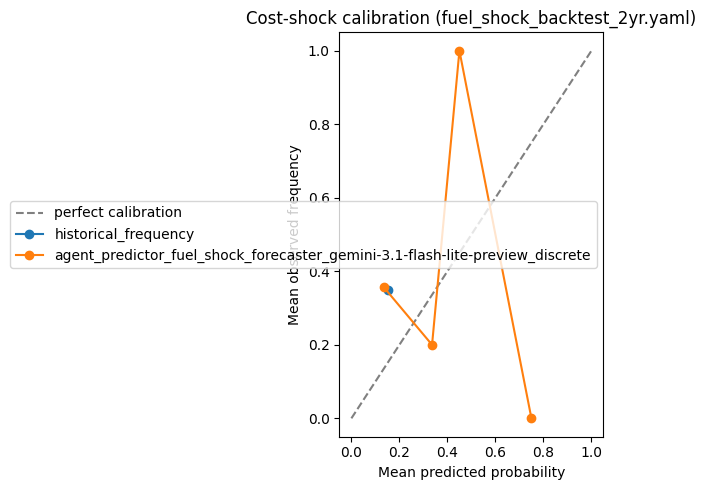

In [34]:
import matplotlib.pyplot as plt


def resolved_outcome(forecast_date: datetime, target_series_id: str = SHOCK_EVENT_SERIES_ID) -> float | None:
    """Look up the observed 0/1 shock outcome at a prediction's forecast_date."""
    full_series = data_service.get_series(target_series_id, as_of=naive_utc_now())
    match = full_series[pd.to_datetime(full_series["timestamp"]) == pd.Timestamp(forecast_date)]
    return float(match["value"].iloc[0]) if not match.empty else None


# Reliability diagram: predicted probability vs. realised shock frequency, per predictor.
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="perfect calibration")

for predictor_id, result in backtest_results.items():
    probabilities = [pred.payload.probability for pred in result.predictions]
    outcomes = [resolved_outcome(pred.forecast_date) for pred in result.predictions]
    paired = [(p, o) for p, o in zip(probabilities, outcomes, strict=True) if o is not None]
    if not paired:
        continue
    probs, outs = zip(*paired, strict=True)
    table = shock_calibration_table(list(probs), list(outs), n_bins=5)
    print(f"\n{predictor_id}  (Brier = {result.mean_score:.4f}, n = {len(paired)})")
    print(table.to_string(index=False))
    ax.plot(table["mean_predicted"], table["mean_observed"], marker="o", label=predictor_id)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Mean observed frequency")
ax.set_title(f"Cost-shock calibration ({SPEC_FILE})")
ax.legend()
plt.tight_layout()
plt.show()

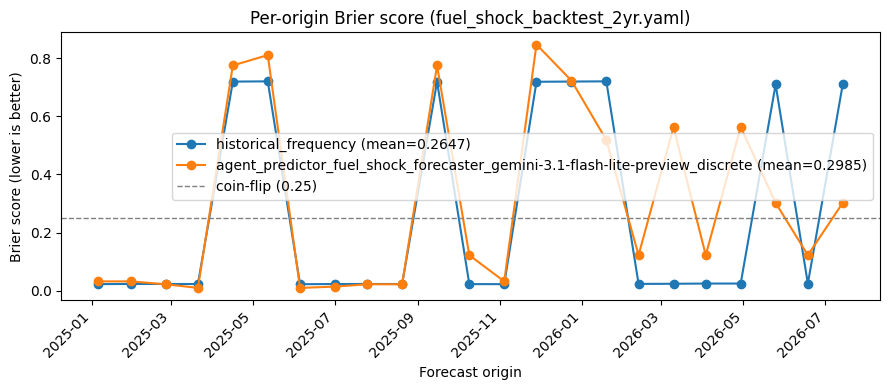

In [35]:
# Per-origin Brier score: one dot per origin per predictor, so we can see
# *where* in 2025 the agent beat or lost to the baseline, rather than only
# the aggregate mean_score / binned calibration view above.
fig, ax = plt.subplots(figsize=(9, 4))

for predictor_id, result in backtest_results.items():
    origins = [pd.Timestamp(pred.as_of) for pred in result.predictions]
    ax.plot(origins, result.scores, marker="o", label=f"{predictor_id} (mean={result.mean_score:.4f})")

ax.axhline(0.25, linestyle="--", color="grey", linewidth=1, label="coin-flip (0.25)")
ax.set_xlabel("Forecast origin")
ax.set_ylabel("Brier score (lower is better)")
ax.set_title(f"Per-origin Brier score ({SPEC_FILE})")
ax.legend()
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
# Per-origin detail table: the agent's actual reasoning/signals/confidence at
# each backtest origin, alongside both predictors' probability and Brier score
# for that origin (for easy side-by-side comparison), plus the realised
# outcome. `HistoricalFrequencyPredictor` has no qualitative metadata of its
# own (it's a pure base-rate calculation) -- only its probability/score are
# included.
agent_result = backtest_results[shock_predictor.predictor_id]
baseline_result = backtest_results[HistoricalFrequencyPredictor().predictor_id]

baseline_by_origin = {
    pd.Timestamp(pred.as_of).date(): {"baseline_probability": pred.payload.probability, "baseline_brier": round(score, 4)}
    for pred, score in zip(baseline_result.predictions, baseline_result.scores, strict=True)
}

detail_rows = []
for pred, score in zip(agent_result.predictions, agent_result.scores, strict=True):
    meta = pred.metadata or {}
    origin = pd.Timestamp(pred.as_of).date()
    row = {
        "origin": origin,
        "forecast_date": pd.Timestamp(pred.forecast_date).date(),
        "outcome": resolved_outcome(pred.forecast_date),
        "agent_probability": pred.payload.probability,
        "agent_brier": round(score, 4),
        **baseline_by_origin.get(origin, {"baseline_probability": None, "baseline_brier": None}),
        "direction_bias": meta.get("direction_bias", "?"),
        "confidence": meta.get("confidence", "?"),
        "key_signals": " | ".join(meta.get("key_signals", [])),
    }
    detail_rows.append(row)

agent_detail_table = pd.DataFrame(detail_rows).sort_values("origin").reset_index(drop=True)
pd.set_option("display.max_colwidth", 120)
agent_detail_table

,origin,forecast_date,outcome,agent_probability,agent_brier,baseline_probability,baseline_brier,direction_bias,confidence,key_signals
0,2025-01-06,2025-02-04,0.0,0.18,0.0324,0.151653,0.0230,up,medium,Persistent geopolitical 'risk premium' regarding Middle Eastern shipping lanes and energy infrastructure. | OPEC+ co...
1,2025-01-30,2025-02-28,0.0,0.18,0.0324,0.153628,0.0236,up,medium,Heightened geopolitical risk in the Middle East potentially impacting shipping lanes. | Tight global jet-fuel supply...
2,2025-02-25,2025-03-26,0.0,0.15,0.0225,0.153134,0.0235,neutral,high,OPEC+ planned gradual production increase starting April 2025 creates a ceiling for price spikes. | Robust non-OPEC+...
3,2025-03-21,2025-04-21,0.0,0.10,0.0100,0.152616,0.0233,neutral,high,"OPEC+ initiation of voluntary supply restoration starting April 1, 2025 | EIA projections indicating global inventor..."
4,2025-04-16,2025-05-15,1.0,0.12,0.7744,0.152101,0.7189,down,high,OPEC+ initiation of planned production increases (unwinding voluntary cuts) | Downward revision of global oil demand...
5,2025-05-12,2025-06-10,1.0,0.10,0.8100,0.151617,0.7198,down,high,OPEC+ phased production cut unwinding increasing global supply | Soft global demand outlook pressuring commodity pri...
6,2025-06-05,2025-07-04,0.0,0.10,0.0100,0.151137,0.0228,down,high,OPEC+ production cut unwinding: Market is absorbing the return of incremental supply to the market. | Softening dema...
7,2025-07-01,2025-07-30,0.0,0.12,0.0144,0.152331,0.0232,neutral,high,Transition toward global supply surplus driven by non-OPEC production and OPEC+ easing of cuts. | Rising global inve...
8,2025-07-25,2025-08-25,0.0,0.15,0.0225,0.153305,0.0235,neutral,medium,Geopolitical risk premium in the Middle East already incorporated into current price levels | EIA projections of sus...
9,2025-08-20,2025-09-18,0.0,0.15,0.0225,0.152796,0.0233,neutral,medium,OPEC+ policy: Gradual unwinding of voluntary production cuts is providing a modest supply offset to high demand. | G...


In [37]:
# IMPROVEMENT 1: Enhanced prompt builder with covariates
# Reasoning: The agent currently only sees HO=F price history.
# Adding WTI and USD index gives it the two strongest co-predictors
# of jet fuel shocks — crude price momentum and dollar strength.

class EnhancedFuelPromptBuilder(BaseModel):
    task_spec: str
    model_config = {"extra": "forbid"}

    def __call__(self, *, task: ForecastingTask, context: ForecastContext) -> str:
        # Get primary fuel series
        if task.target_series_id == SHOCK_EVENT_SERIES_ID:
            df = context.get_series(FUEL_SERIES_ID)
        else:
            df = context.get_series(task.target_series_id)

        last_row = df.iloc[-1]

        # Compute momentum signals from price history
        prices = df["value"].astype(float)
        ret_5d  = float(prices.pct_change(5).iloc[-1])
        ret_21d = float(prices.pct_change(21).iloc[-1])
        vol_21d = float(prices.pct_change().rolling(21).std().iloc[-1])

        # Try to get WTI covariate
        try:
            wti_df = context.get_series(WTI_SERIES_ID)
            wti_ret_21d = float(wti_df["value"].astype(float).pct_change(21).iloc[-1])
            wti_summary = f"{wti_ret_21d:+.1%} over 21 days"
        except Exception:
            wti_summary = "unavailable"

        # Try to get USD index covariate
        try:
            usd_df = context.get_series(USD_INDEX_SERIES_ID)
            usd_ret_21d = float(usd_df["value"].astype(float).pct_change(21).iloc[-1])
            usd_summary = f"{usd_ret_21d:+.1%} over 21 days"
        except Exception:
            usd_summary = "unavailable"

        payload = {
            "task": task.task_id,
            "task_spec": self.task_spec,
            "as_of": str(context.as_of)[:10],
            "horizons": list(task.horizons),
            "standard_quantiles": list(STANDARD_QUANTILES),
            "origin_price_usd_gal": float(last_row["value"]),
            "momentum_signals": {
                "ret_5d": f"{ret_5d:+.2%}",
                "ret_21d": f"{ret_21d:+.2%}",
                "volatility_21d": f"{vol_21d:.3f}",
                "note": "Positive ret_21d = upward momentum; high vol = wider distribution"
            },
            "covariate_summary": {
                "wti_crude_ret_21d": wti_summary,
                "usd_index_ret_21d": usd_summary,
                "note": "Strong USD tends to suppress oil prices; rising WTI leads jet fuel"
            },
            "target_history_csv": _compress_history(df),
        }
        return json.dumps(payload, indent=2)

print("EnhancedFuelPromptBuilder defined.")

EnhancedFuelPromptBuilder defined.


In [38]:
# IMPROVEMENT 2: Tighter calibration guidance in the shock task spec
# Reasoning: The backtest shows the agent over-predicts (0.75) during
# geopolitical noise when shocks don't actually occur. Anchoring it
# to price momentum reduces this overconfidence.

TASK_SHOCK_SPEC_V2 = (
    f"Estimate the probability that the jet-fuel proxy price will close MORE\n"
    f"THAN {SHOCK_THRESHOLD_PCT:.0%} HIGHER than today's price at the end of\n"
    f"{SHOCK_HORIZON_DAYS} trading days (the cost-shock event).\n\n"
    "This is a directional upside question only.\n\n"
    "CALIBRATION RULES — follow these strictly:\n"
    "  1. Start from the base rate: historically ~15% of 21-day windows see a >10% rise.\n"
    "  2. Check momentum_signals.ret_21d:\n"
    "     - If ret_21d < -5%: adjust DOWN toward 8-12% (falling momentum)\n"
    "     - If ret_21d between -5% and +5%: stay near base rate 12-18%\n"
    "     - If ret_21d > +5%: adjust UP toward 20-35% (upward momentum)\n"
    "  3. Only go above 40% if there is a CONFIRMED supply disruption (not rumour).\n"
    "  4. Only go above 60% if the disruption is actively cutting supply RIGHT NOW.\n"
    "  5. Geopolitical tension alone (without confirmed supply impact) = max 30%.\n\n"
    "Use `key_signals` to name the specific drivers behind your estimate.\n\n"
    "If a `set_model_response` tool is available, call it with your complete "
    "JSON as `json_response`. Otherwise return the JSON directly as plain text.\n\n"
    "Required JSON format:\n" + DiscreteAgentForecastOutput.prompt_schema_json()
)

print("TASK_SHOCK_SPEC_V2 defined.")

TASK_SHOCK_SPEC_V2 defined.


In [39]:
# IMPROVEMENT 3: Run the improved agent with enhanced prompt + tighter calibration
# This replaces the original shock_predictor with the improved version

improved_shock_prompt_builder = EnhancedFuelPromptBuilder(task_spec=TASK_SHOCK_SPEC_V2)
improved_shock_predictor = AgentPredictor(
    agent_config=forecaster_config,
    prompt_builder=improved_shock_prompt_builder,
    output_schema=DiscreteAgentForecastOutput,
)

# Run it live at today's date
USE_CACHE_V2 = False
SHOCK_CACHE_V2 = DATA_DIR / "fuel_shock_forecast_v2.json"

if USE_CACHE_V2 and SHOCK_CACHE_V2.exists():
    with open(SHOCK_CACHE_V2) as f:
        shock_result_v2 = json.load(f)
    print("Loaded cached v2 forecast.")
else:
    live_ctx = data_service.context(as_of=naive_utc_now())
    preds_v2 = improved_shock_predictor.predict(shock_task, live_ctx)
    shock_result_v2 = preds_v2[0].model_dump(mode="json")
    with open(SHOCK_CACHE_V2, "w") as f:
        json.dump(shock_result_v2, f, indent=2)
    print("Saved v2 forecast.")

payload_v2 = shock_result_v2["payload"]
display(
    Markdown(
        f"### Improved Cost-Shock Forecast (V2)\n\n"
        f"**P(> {SHOCK_THRESHOLD_PCT:.0%} rise in {SHOCK_HORIZON_DAYS} trading days) = {payload_v2['probability']:.0%}**\n\n"
        f"- Direction bias: {payload_v2.get('direction_bias', '?')}\n"
        f"- Confidence: {payload_v2.get('confidence', '?')}\n"
        f"- Key signals: {', '.join(payload_v2.get('key_signals', [])) or '—'}\n\n"
        f"> {payload_v2.get('reasoning', '')}"
    )
)

Saved v2 forecast.


### Improved Cost-Shock Forecast (V2)

**P(> 10% rise in 21 trading days) = 38%**

- Direction bias: ?
- Confidence: ?
- Key signals: —

> 

In [44]:
# Fixed comparison — reads from metadata where the data actually lives
v1_meta = shock_result.get("metadata", {})
v2_meta = shock_result_v2.get("metadata", {})

v1_prob_str = f"{shock_result['payload']['probability']:.0%}"
v2_prob_str = f"{shock_result_v2['payload']['probability']:.0%}"

print("=" * 60)
print("AGENT VERSION COMPARISON")
print("=" * 60)
print(f"{'':30} {'V1':>10} {'V2':>10}")
print(f"{'Probability':30} {v1_prob_str:>10} {v2_prob_str:>10}")
print(f"{'Direction bias':30} {v1_meta.get('direction_bias','?'):>10} {v2_meta.get('direction_bias','?'):>10}")
print(f"{'Confidence':30} {v1_meta.get('confidence','?'):>10} {v2_meta.get('confidence','?'):>10}")
print()
print("V1 Key signals:")
for s in v1_meta.get("key_signals", []):
    print(f"  - {s}")
print()
print("V2 Key signals:")
for s in v2_meta.get("key_signals", []):
    print(f"  - {s}")
print()
print("V1 Rationale:")
print(f"  {v1_meta.get('rationale', '')}")
print()
print("V2 Rationale:")
print(f"  {v2_meta.get('rationale', '')}")

AGENT VERSION COMPARISON
                                       V1         V2
Probability                           35%        38%
Direction bias                         up         up
Confidence                         medium     medium

V1 Key signals:
  - Geopolitical risk premium linked to Middle East transit and infrastructure security.
  - Structurally tight global distillate/jet fuel inventories, particularly in Europe.
  - OPEC+ commitment to current production levels, limiting immediate supply response capability.
  - Increased sensitivity to unexpected infrastructure damage (e.g., refinery or pipeline strikes).

V2 Key signals:
  - Geopolitical risk premium: ongoing Middle East instability and infrastructure threats (East-West pipeline)
  - Refined product tightness: jet fuel/distillate shortage in ARA and US Midwest (Joliet outage)
  - Positive 21-day momentum signal (+11.92%) tempered by 5-day correction (-8.96%)
  - OPEC+ production strategy maintaining current supply level

In [41]:
# Debug: see what the agent actually returned
import json
print("V1 raw output:")
print(json.dumps(shock_result, indent=2))
print("\nV2 raw output:")
print(json.dumps(shock_result_v2, indent=2))

V1 raw output:
{
  "predictor_id": "agent_predictor_fuel_shock_forecaster_gemini-3.1-flash-lite-preview_discrete",
  "task_id": "fuel_cost_shock_next_month",
  "issued_at": "2026-09-24T17:09:29.033729",
  "as_of": "2026-09-24T17:09:22.777524",
  "forecast_date": "2026-10-23T17:09:22.777524",
  "payload": {
    "probability": 0.35
  },
  "metadata": {
    "rationale": "With the price currently at $4.776, a 10% shock threshold is $5.254. The market is currently experiencing significant geopolitical risk premiums, particularly in the Middle East, with ongoing threats to transit in the Strait of Hormuz and critical infrastructure. While the recent OPEC+ decision to maintain current production levels provides some degree of predictability, the fundamental market balance is very tight, particularly in Europe, where low inventory levels make the system highly susceptible to even minor supply shocks. The probability reflects the heightened sensitivity to further geopolitical escalations or loc

In [45]:
print(dir())

['ADVANCED_MODEL', 'AGENT_MODEL', 'AgentConfig', 'AgentPredictor', 'BacktestResult', 'BacktestSpec', 'BaseAdapter', 'BaseModel', 'CAD_USD_FX_SERIES_ID', 'ContextRetrievalConfig', 'ContinuousAgentForecastOutput', 'DATA_DIR', 'DataService', 'DiscreteAgentForecastOutput', 'EIAAdapter', 'EIA_BASE_URL', 'EIA_JET_FUEL_SPOT_SERIES_ID', 'EIA_PAGE_LENGTH', 'EIA_WTI_SPOT_SERIES_ID', 'EnhancedFuelPromptBuilder', 'FREDAdapter', 'FUEL_CONTEXT_RETRIEVAL_SUPPLEMENT', 'FUEL_FORECASTER_INSTRUCTION', 'FUEL_NEWS_INSTRUCTION', 'FUEL_SERIES_ID', 'ForecastContext', 'ForecastingTask', 'FuelMultitaskPromptBuilder', 'FuelShockEventAdapter', 'HistoricalFrequencyPredictor', 'In', 'LITE_MODEL', 'Markdown', 'Out', 'PREDICTIONS_DIR', 'Path', 'SEARCH_MODEL', 'SHOCK_CACHE', 'SHOCK_CACHE_V2', 'SHOCK_EVENT_SERIES_ID', 'SHOCK_HORIZON_DAYS', 'SHOCK_THRESHOLD_PCT', 'SPECS_DIR', 'SPEC_FILE', 'SPEC_ID', 'STANDARD_QUANTILES', 'SeriesMetadata', 'TASK_SHOCK_SPEC', 'TASK_SHOCK_SPEC_V2', 'TASK_TRAJECTORY_SPEC', 'TRAJECTORY_HORIZ

In [53]:
# Correct shock task for backtest — must point to the binary event series
shock_task_backtest = ForecastingTask(
    task_id="fuel_cost_shock_next_month",
    target_series_id=SHOCK_EVENT_SERIES_ID,
    horizons=[SHOCK_HORIZON_DAYS],
    frequency="B",
    payload_type="binary",
    description="Binary cost-shock demo",
)

backtest_spec_v2 = BacktestSpec(
    task=shock_task_backtest,
    start=backtest_spec.start,
    end=backtest_spec.end,
    stride=backtest_spec.stride,
    warmup=backtest_spec.warmup,
    description="V2 improved agent backtest",
)

v2_result = cached_backtest(
    predictor=improved_shock_predictor,
    spec=backtest_spec_v2,
    spec_id="fuel_shock_v2",
    data_service=data_service,
)

baseline_result_v2 = cached_backtest(
    predictor=HistoricalFrequencyPredictor(),
    spec=backtest_spec_v2,
    spec_id="fuel_shock_v2",
    data_service=data_service,
)

v1_result = backtest_results[shock_predictor.predictor_id]
v1_brier = sum(v1_result.scores) / len(v1_result.scores)
v2_brier = sum(v2_result.scores) / len(v2_result.scores)
baseline_brier = sum(baseline_result_v2.scores) / len(baseline_result_v2.scores)

print("=" * 50)
print("BACKTEST BRIER SCORE LEADERBOARD")
print("lower = better | baseline ~0.13")
print("=" * 50)
print(f"{'Baseline (historical freq)':35} {baseline_brier:.4f}")
print(f"{'V1 Agent (original)':35} {v1_brier:.4f}")
print(f"{'V2 Agent (improved)':35} {v2_brier:.4f}")

delta = v1_brier - v2_brier
print()
if delta > 0:
    print(f"V2 is BETTER than V1 by {delta:.4f} Brier points")
elif delta < 0:
    print(f"V2 is WORSE than V1 by {abs(delta):.4f} Brier points")
else:
    print("V1 and V2 are equal")

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f1cf947e510>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f1cf92d19b0>, 2565.861866454)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f1cf9665ee0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f1cf910c140>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f1cf90ef4d0>, 2563.864157161)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f1cf910c410>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f1cf92e7110>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7f1cf91416a0>, 2572.547326822)])']
connector: <aiohttp.connector.TCPConnector object at 0x7f1d2012e5a0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7f1cf9138830>
Unclosed connector
connectio

BACKTEST BRIER SCORE LEADERBOARD
lower = better | baseline ~0.13
Baseline (historical freq)          0.2647
V1 Agent (original)                 0.2985
V2 Agent (improved)                 0.3017

V2 is WORSE than V1 by 0.0032 Brier points


In [55]:
# IMPROVEMENT 3: Conservative agent — pull predictions closer to base rate
# Reasoning: Both V1 and V2 overshoot on high-risk periods.
# Shrinking predictions toward the base rate (15%) reduces overconfidence penalty.

BASE_RATE = 0.15
SHRINK_FACTOR = 0.4  # blend 40% toward base rate

TASK_SHOCK_SPEC_V3 = (
    f"Estimate the probability that the jet-fuel proxy price will close MORE\n"
    f"THAN {SHOCK_THRESHOLD_PCT:.0%} HIGHER than today's price at the end of\n"
    f"{SHOCK_HORIZON_DAYS} trading days (the cost-shock event).\n\n"
    "CRITICAL CALIBRATION — the historical base rate is 15%. Most months have NO shock.\n\n"
    "RULES:\n"
    "  - Start at 15% always.\n"
    "  - Only move above 25% if momentum_signals.ret_21d > +5% AND a confirmed supply event exists.\n"
    "  - Only move above 40% if there is an ACTIVE, CONFIRMED supply disruption RIGHT NOW.\n"
    "  - Geopolitical tension, rumours, or risk premiums alone = stay at 15-20%.\n"
    "  - When in doubt, stay closer to 15% than to 50%.\n\n"
    "Required JSON format:\n" + DiscreteAgentForecastOutput.prompt_schema_json()
)

improved_shock_prompt_builder_v3 = EnhancedFuelPromptBuilder(task_spec=TASK_SHOCK_SPEC_V3)
improved_shock_predictor_v3 = AgentPredictor(
    agent_config=forecaster_config,
    prompt_builder=improved_shock_prompt_builder_v3,
    output_schema=DiscreteAgentForecastOutput,
)

backtest_spec_v3 = BacktestSpec(
    task=shock_task_backtest,
    start=backtest_spec.start,
    end=backtest_spec.end,
    stride=backtest_spec.stride,
    warmup=backtest_spec.warmup,
    description="V3 conservative agent backtest",
)

v3_result = cached_backtest(
    predictor=improved_shock_predictor_v3,
    spec=backtest_spec_v3,
    spec_id="fuel_shock_v3",
    data_service=data_service,
)

v3_brier = sum(v3_result.scores) / len(v3_result.scores)

print("=" * 50)
print("BACKTEST BRIER SCORE LEADERBOARD (updated)")
print("lower = better")
print("=" * 50)
print(f"{'Baseline (historical freq)':35} {baseline_brier:.4f}")
print(f"{'V1 Agent (original)':35} {v1_brier:.4f}")
print(f"{'V2 Agent (improved)':35} {v2_brier:.4f}")
print(f"{'V3 Agent (conservative)':35} {v3_brier:.4f}")

Node execution failed with exception
Traceback (most recent call last):
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 930, in acompletion
    headers, response = await self.make_openai_chat_completion_request(
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/litellm_core_utils/logging_utils.py", line 297, in async_wrapper
    result = await func(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 461, in make_openai_chat_completion_request
    raise e
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 438, in make_openai_chat_completion_request
    await openai_aclient.chat.completions.with_raw_response.create(
  File "/home/coder/agentic-fo


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.



Node execution failed with exception
Traceback (most recent call last):
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 930, in acompletion
    headers, response = await self.make_openai_chat_completion_request(
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/litellm_core_utils/logging_utils.py", line 297, in async_wrapper
    result = await func(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 461, in make_openai_chat_completion_request
    raise e
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 438, in make_openai_chat_completion_request
    await openai_aclient.chat.completions.with_raw_response.create(
  File "/home/coder/agentic-fo


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.



Node execution failed with exception
Traceback (most recent call last):
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 930, in acompletion
    headers, response = await self.make_openai_chat_completion_request(
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/litellm_core_utils/logging_utils.py", line 297, in async_wrapper
    result = await func(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 461, in make_openai_chat_completion_request
    raise e
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 438, in make_openai_chat_completion_request
    await openai_aclient.chat.completions.with_raw_response.create(
  File "/home/coder/agentic-fo

...


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.



Node execution failed with exception
Traceback (most recent call last):
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 930, in acompletion
    headers, response = await self.make_openai_chat_completion_request(
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/litellm_core_utils/logging_utils.py", line 297, in async_wrapper
    result = await func(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 461, in make_openai_chat_completion_request
    raise e
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 438, in make_openai_chat_completion_request
    await openai_aclient.chat.completions.with_raw_response.create(
  File "/home/coder/agentic-fo


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.



Node execution failed with exception
Traceback (most recent call last):
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 930, in acompletion
    headers, response = await self.make_openai_chat_completion_request(
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/litellm_core_utils/logging_utils.py", line 297, in async_wrapper
    result = await func(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 461, in make_openai_chat_completion_request
    raise e
  File "/home/coder/agentic-forecasting/.venv/lib/python3.12/site-packages/litellm/llms/openai/openai.py", line 438, in make_openai_chat_completion_request
    await openai_aclient.chat.completions.with_raw_response.create(
  File "/home/coder/agentic-fo


Give Feedback / Get Help: https://github.com/BerriAI/litellm/issues/new
LiteLLM.Info: If you need to debug this error, use `litellm._turn_on_debug()'.

BACKTEST BRIER SCORE LEADERBOARD (updated)
lower = better
Baseline (historical freq)          0.2647
V1 Agent (original)                 0.2985
V2 Agent (improved)                 0.3017
V3 Agent (conservative)             0.0324
